In [78]:
% setup environment
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
last_slash_pos = rindex(rootpath, "/");
rootpath=rootpath(1:last_slash_pos);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% clear data and number format
clear; format short e
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
graphics_toolkit ("plotly"); 
%graphics_toolkit("gnuplot")

In [79]:
% define equilibrium problem

FeT=1e-5; pH=2:0.5:12; pe=20.75-pH; 

In [80]:
function [Fep3,FeLOHR3s,FeLOHR2s,Fep2,MASSERR]=Fetableau(pH,pe,T,flag0,flag1,flag2,flag3,flag4,flag5)

% input tableau.  change this part % ----------------------------------------------

Tableau=[...
{'H+'} {'e-'} {'Fe+3'}    {'logK'}                    {'phase'}    {'species'} 
1       0        0           0                           0          {'H+'}
0       1        0           0                           0          {'e-'}
0       0        1           0                           0          {'Fe+3'}
% Kw
-1      0        0         -14                           0          {'OH-'}
% hydroloysis/redox products
0       1        1           13.92                       0          {'Fe+2'}
-1      0        1           -2.19                       0          {'Fe(OH)+2'}
-2      0        1           -5.67                       0          {'Fe(OH)2+'}
-3      0        1           -12.56                      0          {'Fe(OH)3'}
-4      0        1           -21.6                       0          {'Fe(OH)4-'}
-2      0        2           -2.95                       0          {'Fe2(OH)2+4'}
-4      0        3           -6.3                        0          {'Fe3(OH)4+5'}
-1      1        1           -3.52                       0          {'Fe(OH)+'}
-2      1        1           -7.55                       0          {'Fe(OH)2'}
-3      1        1           -17.98                      0          {'Fe(OH)3-'}
%solids
-3      0        1           -4.891                      1          {'Fe(OH)3s'} %HFO
-2      1        1           0.82                        1          {'Fe(OH)2s'} %HFeIIO
];


% end of tableau.  ------------------ % ----------------------------------------------

if flag0==0 % solve with tableau (using other flags for options)

[KSOLID,ASOLID,SOLIDNAMES,KSOLUTION,ASOLUTION,SOLUTIONNAMES]=processtableau(Tableau(2:end,1:end),pH,pe);
    [SPECIESCONCS,SPECIATIONNAMES,masserr,X]=returnspeciationRE(KSOLID,ASOLID,SOLIDNAMES,KSOLUTION,ASOLUTION,SOLUTIONNAMES,...
    T,flag1,flag2,flag3,flag4,flag5);
    for k=1:size(SPECIESCONCS,1)
          txt=[SPECIATIONNAMES(k,:),'=SPECIESCONCS(k);'];
          eval(txt)
    end
    
    %[MASSERR,IDX]=max((MASSERR)); % oops. this would ignore negative errors
    %MASSERR=max(100*((MASSERR)./T)); % relative does not make sense when some components are so tiny (like HFOinitial conc)
    [MASSERR,INDX]=max(abs(masserr)); MASSERR=MASSERR*sign(masserr(INDX));
end

end 

In [81]:
% MODEL USING TABLEAU (different gradients or log versus linear variables)
%graphics_toolkit("notebook")
%model with just inorganic speciation
%geochemical model
% input the constants and solution chemistry
flag0=0; %choose solver. 0 for tableau and 1 for phreeqc-based solver
flag1=2; %flag1 for concentration based search vector (1) or for log based search vector (2).
flag2=1; %flag2 for numerical derivatives (2) or analtyical derivatives (1)
flag3=0; % flag3 1 for show warnings. 0 no warnings
flag4=1; %if=1 solve tableau one line at a time to get a good initial guess (no solids). really challenging probs only
flag5=0; %if=1 use stored initial guess for including solids

TOTALS=[FeT]';
TOTALS(TOTALS==0)=1e-16; % get rid of zero values, b/c div by zero error

pE=0:1.5:20.75;
for i=1:length(pH)
    for j=1:length(pE)
        pe=pE(j)-pH;
        pHmatrix(i,j)=pH(i);
        pematrix(i,j)=pe(i);
    end
end

for i=1:length(pH)
    for j=1:length(pE)
        [Fep3(i,j),HFO(i,j),HF2O(i,j),Fep2(i,j),MASSERR(i,j)]=Fetableau(pHmatrix(i,j),pematrix(i,j),TOTALS',flag0,flag1,flag2,flag3,flag4,flag5);
    end
end

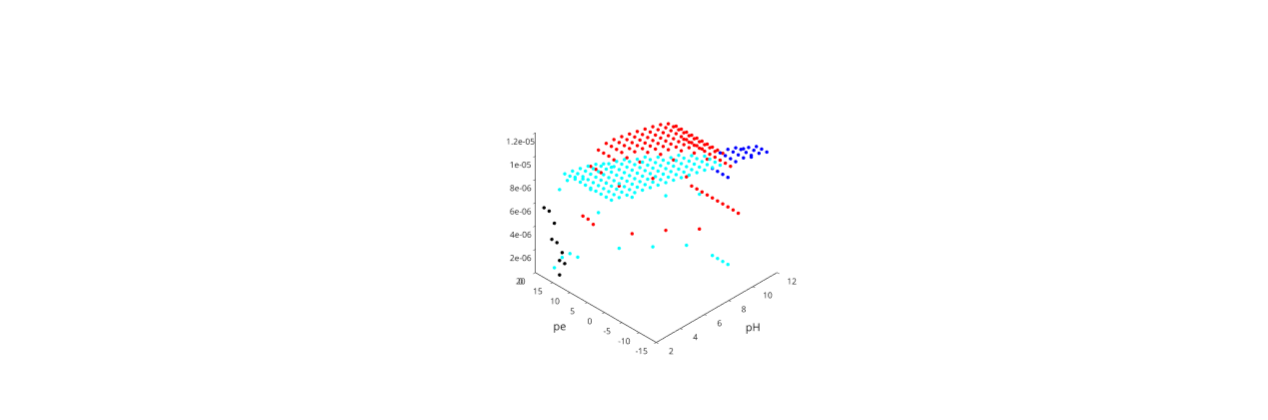

In [92]:
graphics_toolkit ("plotly"); 
power=HFO*10;
pHvector=reshape(pHmatrix,1,[]);
pevector=reshape(pematrix,1,[]);
threshold=1e-6;
HFOvector=reshape(HFO,1,[]); HFOvector(HFOvector<threshold)=NaN;
HF2Ovector=reshape(HF2O,1,[]); HF2Ovector(HF2Ovector<threshold)=NaN;
Fep2vector=reshape(Fep2,1,[]); Fep2vector(Fep2vector<threshold)=NaN;
Fep3vector=reshape(Fep3,1,[]); Fep3vector(Fep3vector<threshold)=NaN;

plot3(pHvector,pevector,HFOvector,'ro')
hold on
plot3(pHvector,pevector,HF2Ovector,'bo')
plot3(pHvector,pevector,Fep2vector,'co')
plot3(pHvector,pevector,Fep3vector,'ko')

xlabel('pH'); ylabel('pe')

%scatter3(pHvector,pevector,HFOvector,10,HFOvector)
%colormap('winter')
%colorbar
%view([0 90])


In [83]:
%plot(pH,MASSERR)